In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
FIELDVARS  = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'

SRMODELS = CONFIGS['experiments']['sr']['optimizedeqs']

SRFUNCTIONS = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'sin':np.sin,'cos':np.cos,'max':np.maximum,'min':np.minimum,
    '_safepow':lambda a,b:np.abs(a)**b}

import re
def _prepare_form(form):
    return re.sub(r'(\w+)\^(\w+)',r'_safepow(\1,\2)',form)

def eval_form(form,columns,constants):
    ns = dict(SRFUNCTIONS,__builtins__={})
    ns.update(columns)
    ns.update(constants)
    out = eval(_prepare_form(form),ns)
    if np.ndim(out)==0:
        n = len(next(v for v in columns.values() if hasattr(v,'__len__')))
        out = np.full(n,float(out))
    return np.asarray(out,dtype=float)

In [4]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
MEAN = STATS['tp_mean']
STD  = STATS['tp_std']
ZMIN = (0.0 - MEAN) / STD

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']
    nlat  = ds.sizes['lat']
    nlon  = ds.sizes['lon']
    nsig  = ds.sizes.get('sig',1)
    lat,lon = ds.lat.values,ds.lon.values
    dsig  = ds['dsig'].values
    fields = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS],axis=1)
    surfmask = ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig) if 'surfmask' in ds else None
    flat = lambda v: ds[v].transpose('time','lat','lon').values.ravel() if 'time' in ds[v].dims else np.tile(ds[v].values,(ntime,1,1)).ravel()
    lfraw = flat('lf')
    shfraw = flat('shf')
    lhfraw = flat('lhf')
    blraw = flat('bl') if 'bl' in ds else np.zeros(ntime*nlat*nlon)

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsraw = ds['tp'].transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds.k.values)
meankernel = np.mean(kernels,axis=0)
weighted = fields * meankernel[None,:,:] * dsig[None,None,:]
if surfmask is not None:
    weighted = weighted * surfmask[:,None,:]
integrals = weighted.sum(axis=2)
rhraw,thetaeraw,thetaestarraw = integrals[:,0],integrals[:,1],integrals[:,2]

valid = np.isfinite(rhraw) & np.isfinite(thetaeraw) & np.isfinite(thetaestarraw) & np.isfinite(obsraw)
rh,thetae,thetaestar = rhraw[valid],thetaeraw[valid],thetaestarraw[valid]
lf,shf,lhf = lfraw[valid],shfraw[valid],lhfraw[valid]
bl = blraw[valid]
obs = obsraw[valid]

def to_map(flat):
    full = np.full(ntime*nlat*nlon,np.nan)
    full[valid] = flat
    return np.nanmean(full.reshape(ntime,nlat,nlon),axis=0)

print(f'Loaded {valid.sum():,} valid samples')

Loaded 1,437,408 valid samples


In [5]:
regdf = pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv'))
REGISTRY = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),
                              train_loss=row['train_loss'],valid_loss=row['valid_loss'])
             for _,row in regdf.iterrows()}
ORDER  = [name for name in SRMODELS if name in REGISTRY]
LABELS = {name:SRMODELS[name]['description'] for name in ORDER}
COLORS = {name:SRMODELS[name]['color'] for name in ORDER}

def get_columns(**overrides):
    cols = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,
            'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    cols.update(overrides)
    for eqname,entry in REGISTRY.items():
        if eqname in overrides:
            continue
        cols[eqname] = eval_form(entry['form'],cols,entry['constants'])
    return cols

def predict_eq(name,columns):
    entry = REGISTRY[name]
    raw = eval_form(entry['form'],columns,entry['constants'])
    z = ZMIN + np.maximum(raw,0.0)
    return np.maximum(np.expm1(z * STD + MEAN),0.0)

def to_phys(znorm):
    return np.maximum(np.expm1(np.maximum(znorm,ZMIN) * STD + MEAN),0.0)

def bin_1d(x,z,nbins=20,minsamples=50,plo=1,phi=99):
    mask = np.isfinite(x)&np.isfinite(z)
    x,z  = x[mask],z[mask]
    edges  = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    xi     = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    counts = np.bincount(xi,minlength=nbins)
    sums   = np.bincount(xi,weights=z,minlength=nbins)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

def bin_2d(x,y,z,nbins=20,minsamples=50,plo=1,phi=99):
    mask  = np.isfinite(x)&np.isfinite(y)&np.isfinite(z)
    x,y,z = x[mask],y[mask],z[mask]
    xe = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    ye = np.linspace(*np.percentile(y,[plo,phi]),nbins+1)
    xi = np.clip(np.digitize(x,xe)-1,0,nbins-1)
    yi = np.clip(np.digitize(y,ye)-1,0,nbins-1)
    idx    = xi*nbins+yi
    counts = np.bincount(idx,minlength=nbins*nbins).reshape(nbins,nbins)
    sums   = np.bincount(idx,weights=z,minlength=nbins*nbins).reshape(nbins,nbins)
    return (0.5*(xe[:-1]+xe[1:]),0.5*(ye[:-1]+ye[1:]),
            np.where(counts>=minsamples,sums/counts,np.nan),counts)

COLS = get_columns()
PRED = {name:predict_eq(name,COLS) for name in ORDER}

for name in ORDER:
    entry = REGISTRY[name]
    print(f'{LABELS[name]}: {entry["form"]}  {entry["constants"]}')

SR-BL: cube(bl+a)+b  {'a': 0.3, 'b': 0.14}
SR-ATM: a*cube(max(rh,thetae-b*thetaestar-c))  {'a': 1.57, 'b': 1.48, 'c': 0.37}
SR-SFC: sr_atm_eq+a*shf*(b-lf)+c*lhf  {'a': 1.0, 'b': 0.74, 'c': 0.21}
SR-ALL: sr_atm_eq+(thetae+a*shf)*cube(b-lf)+c  {'a': 5.24, 'b': 0.73, 'c': -0.12}


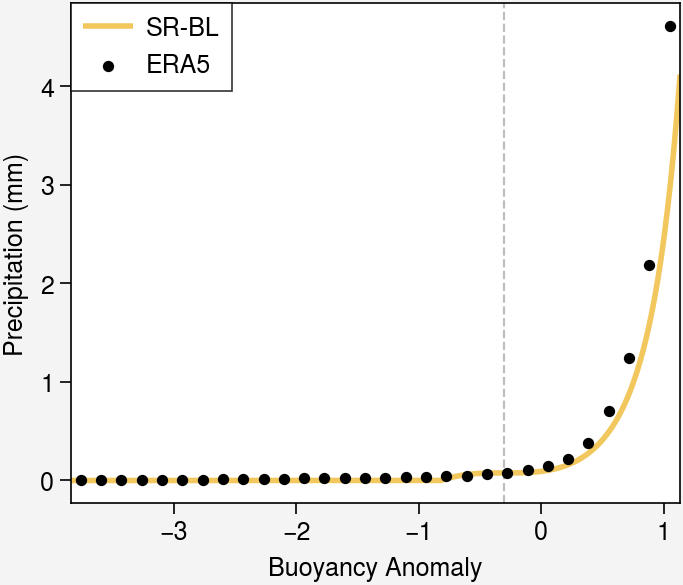

In [18]:
cbl = REGISTRY['sr_bl_eq']['constants']

centers,obsmean,_ = bin_1d(bl,obs,nbins=30)
blrange = np.linspace(np.percentile(bl,1),np.percentile(bl,99),200)
blanalytic = to_phys(ZMIN + np.maximum((blrange+cbl['a'])**3+cbl['b'],0.0))

fig,ax = pplt.subplots(figwidth=3.5,refheight=2.5)
ax.scatter(centers,obsmean,color='k',s=12,zorder=3,label='ERA5')
ax.plot(blrange,blanalytic,color=COLORS['sr_bl_eq'],linewidth=2,label='SR-BL')
ax.axvline(-cbl['a'],color='gray',linewidth=0.8,linestyle='--',alpha=0.6)
ax.format(grid=False,
          xlabel=r'Buoyancy Anomaly',
          ylabel='Precipitation (mm)')
ax.legend(loc='ul',ncols=1)
fig.save('../figs/fig_3.jpg')

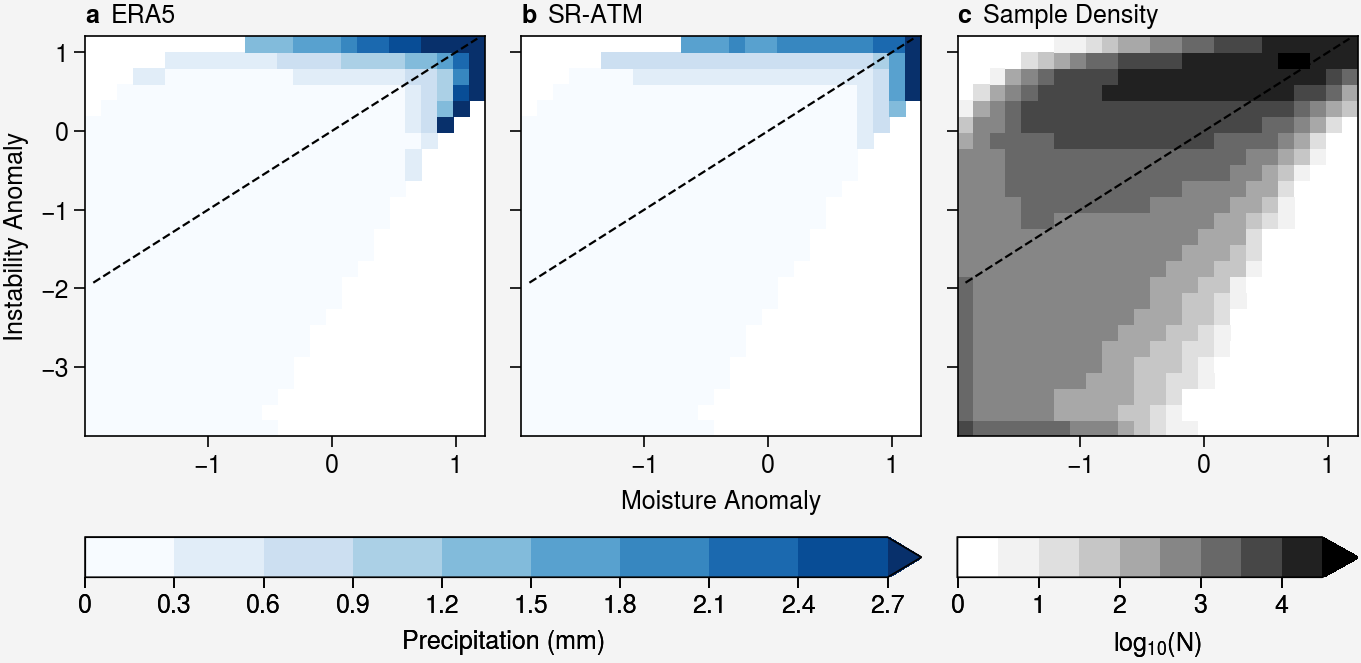

In [26]:
ca = REGISTRY['sr_atm_eq']['constants']
moisture    = rh
instability = thetae - ca['b']*thetaestar - ca['c']

mc,ic,obsmean2d,counts2d = bin_2d(moisture,instability,obs,nbins=25)
_,_,predmean2d,_ = bin_2d(moisture,instability,PRED['sr_atm_eq'],nbins=25)
logcounts = np.where(counts2d>0,np.log10(counts2d),np.nan)

fig,axs = pplt.subplots(ncols=3,refheight=2,share=True)
kwax = dict(grid=False,
            xlabel=r'Moisture Anomaly',
            ylabel=r'Instability Anomaly')

m1 = axs[0].pcolormesh(mc,ic,obsmean2d.T,cmap='Blues',vmin=0,vmax=3,extend='max')
axs[0].plot([mc.min(),mc.max()],[mc.min(),mc.max()],color='k',linewidth=0.8,linestyle='--')
axs[0].format(title='ERA5',**kwax)

m2 = axs[1].pcolormesh(mc,ic,predmean2d.T,cmap='Blues',vmin=0,vmax=3,extend='max')
axs[1].plot([mc.min(),mc.max()],[mc.min(),mc.max()],color='k',linewidth=0.8,linestyle='--')
axs[1].format(title='SR-ATM',**kwax)
fig.colorbar(m1,cols=(1,2),loc='b',title='Precipitation (mm)')

m3 = axs[2].pcolormesh(mc,ic,logcounts.T,cmap='Greys',vmin=0,extend='max')
axs[2].plot([mc.min(),mc.max()],[mc.min(),mc.max()],color='k',linewidth=0.8,linestyle='--')
axs[2].format(title='Sample Density',**kwax)
cb = fig.colorbar(m3,loc='b',col=3)
cb.set_label(r'log$_{10}$(N)')

axs.format(abc=True,titleloc='l')
fig.save('../figs/fig_4.jpg')

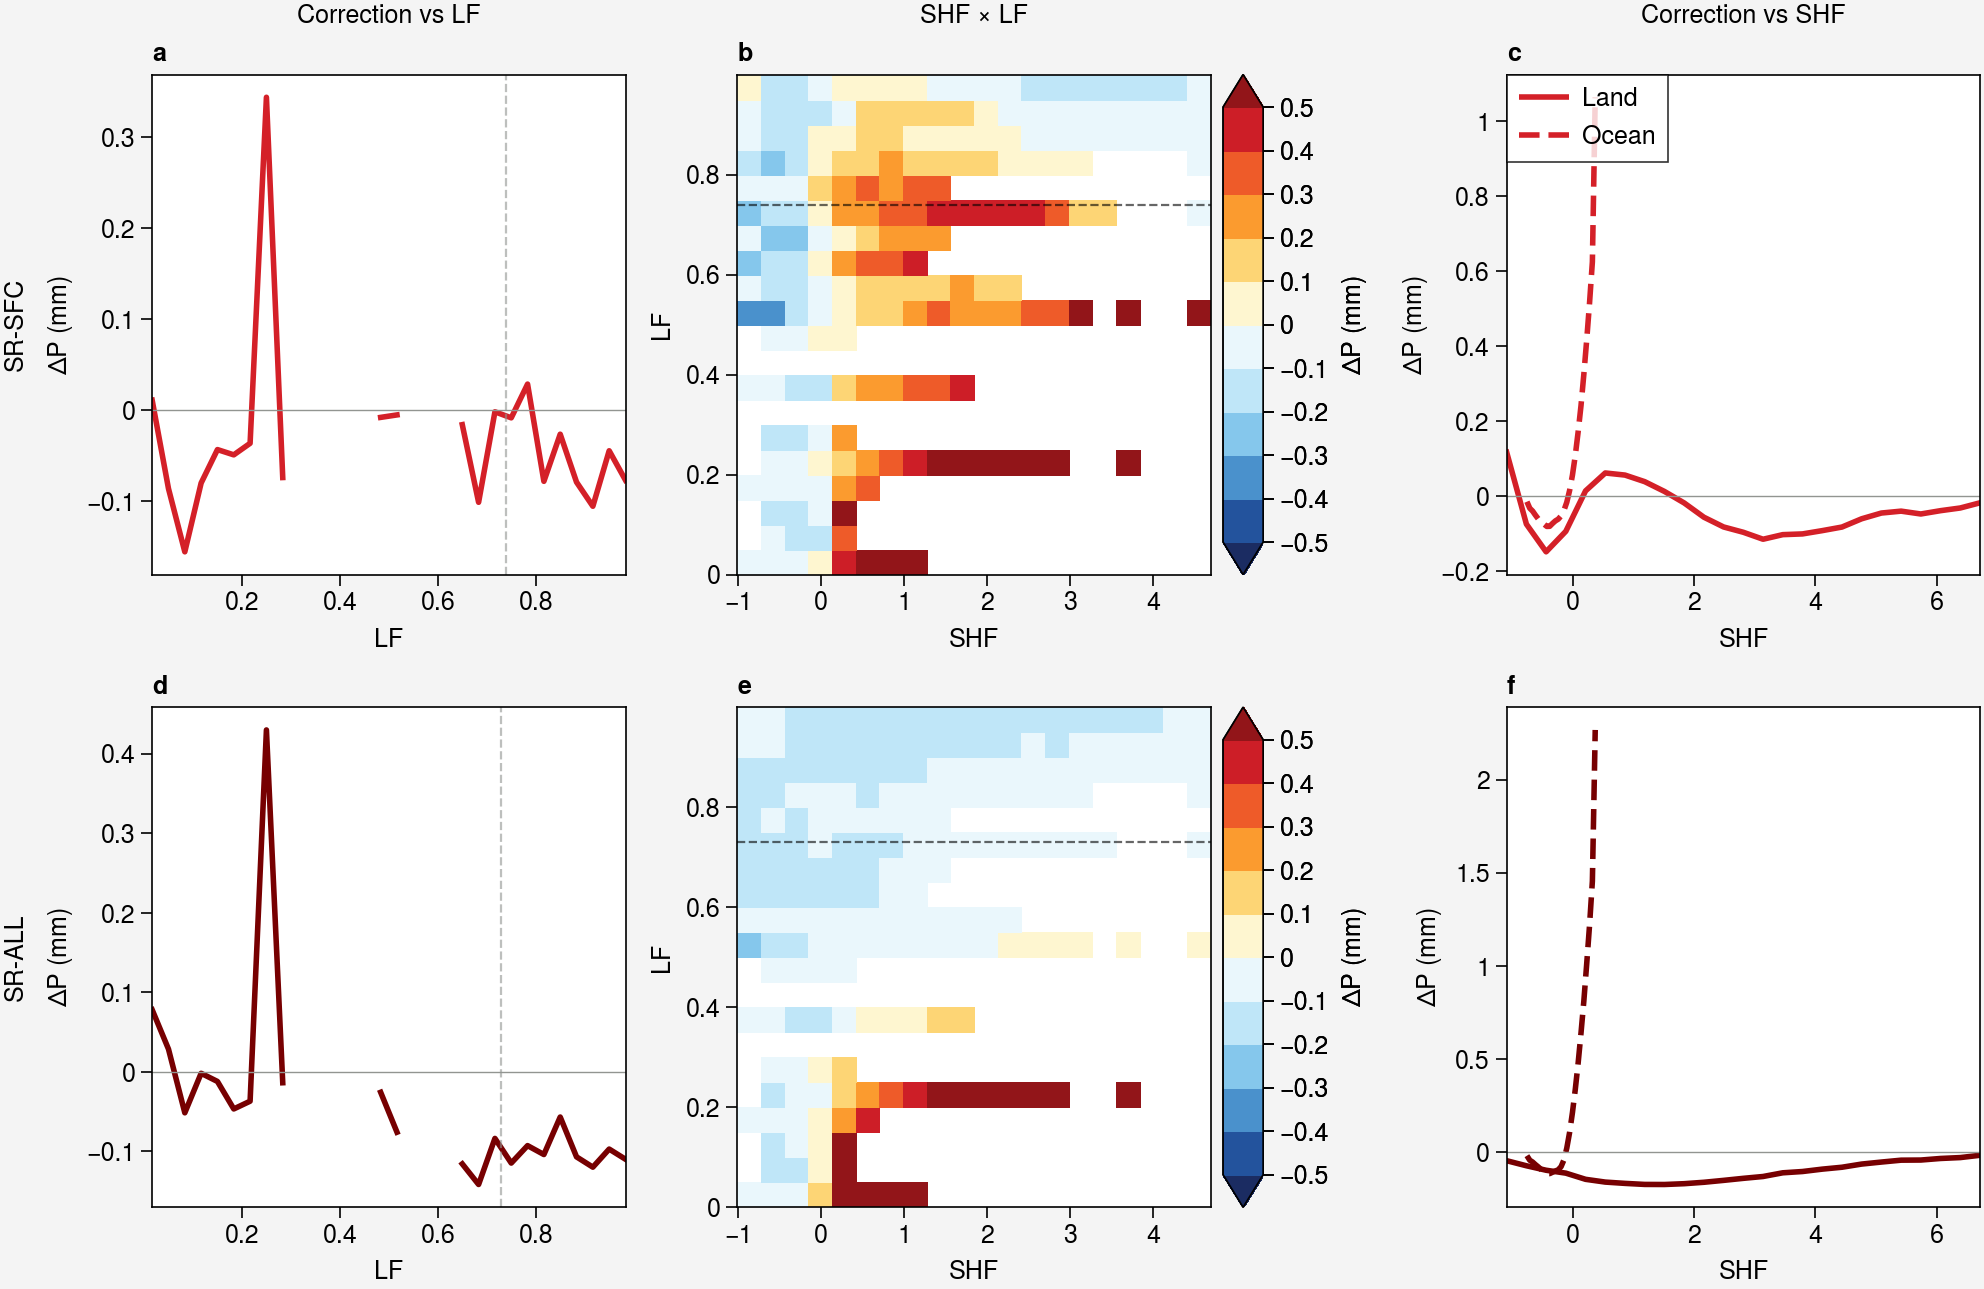

In [27]:
corr_sfc = PRED['sr_sfc_eq'] - PRED['sr_atm_eq']
corr_all = PRED['sr_all_eq'] - PRED['sr_atm_eq']
csfc = REGISTRY['sr_sfc_eq']['constants']
call = REGISTRY['sr_all_eq']['constants']

fig,axs = pplt.subplots(nrows=2,ncols=3,figwidth=10,refheight=2.5,
                        sharex=False,sharey=False)

for row,name,corr,consts in [(0,'sr_sfc_eq',corr_sfc,csfc),
                              (1,'sr_all_eq',corr_all,call)]:
    centers,corrm,_ = bin_1d(lf,corr,nbins=30)
    axs[row,0].plot(centers,corrm,color=COLORS[name],linewidth=2)
    axs[row,0].axhline(0,color='gray',linewidth=0.5)
    axs[row,0].axvline(consts['b'],color='gray',linewidth=0.8,linestyle='--',alpha=0.6)
    axs[row,0].format(grid=False,xlabel='LF',ylabel=r'$\Delta$P (mm)')

    xc,yc,corr2d,cnt = bin_2d(shf,lf,corr,nbins=20)
    m = axs[row,1].pcolormesh(xc,yc,corr2d.T,cmap='ColdHot',vmin=-0.5,vmax=0.5,extend='both')
    axs[row,1].axhline(consts['b'],color='k',linewidth=0.8,linestyle='--',alpha=0.6)
    axs[row,1].format(grid=False,xlabel='SHF',ylabel='LF')
    axs[row,1].colorbar(m,loc='r',label=r'$\Delta$P (mm)')

    centers2,corrm2,_ = bin_1d(shf,corr,nbins=30)
    landmask = lf > 0.5
    cland,corrland,_ = bin_1d(shf[landmask],corr[landmask],nbins=25)
    cocean,corrocean,_ = bin_1d(shf[~landmask],corr[~landmask],nbins=25)
    axs[row,2].plot(cland,corrland,color=COLORS[name],linewidth=2,label='Land')
    axs[row,2].plot(cocean,corrocean,color=COLORS[name],linewidth=2,
                    linestyle='--',label='Ocean')
    axs[row,2].axhline(0,color='gray',linewidth=0.5)
    axs[row,2].format(grid=False,xlabel='SHF',ylabel=r'$\Delta$P (mm)')
    if row==0:
        axs[row,2].legend(loc='ul',ncols=1)

axs.format(abc=True,titleloc='l',
           rowlabels=[LABELS[n] for n in ['sr_sfc_eq','sr_all_eq']],
           collabels=['Correction vs LF','SHF \u00d7 LF','Correction vs SHF'])
fig.save('../figs/fig_5.jpg')